# Strain-level analyses from WGS dataset
## inStrain nucleotide diversity and dN/dS analysis

Date created: 11/3/2024

Notebook authors: Yang Chen

Data analysis by: Yang Chen

This notebook plots the following:

- Nucleotide diversity results from inStrain based on MAGs grouped at species level
- Nucleotide diversity results from inStrain based on MAGs grouped by _C. acnes_ MLST strain type
- dN/dS analysis (TBD)

In [33]:
# Import Python packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter
from scipy.stats import mannwhitneyu
import itertools
from scipy.stats import kruskal
from matplotlib.ticker import ScalarFormatter
import matplotlib.colors as mcolors
import statannot


In [34]:
# Read in inStrain merged genome info file
path = '../Data/metaG/inStrain_files/inStrain_merged_genome_info.tsv'
df = pd.read_csv(path, sep='\t')
df

,genome,coverage,breadth,nucl_diversity,length,true_scaffolds,detected_scaffolds,coverage_median,coverage_std,coverage_SEM,...,d_prime_mean,consensus_divergent_sites,population_divergent_sites,SNS_count,SNV_count,filtered_read_pair_count,reads_unfiltered_pairs,reads_mean_PID,reads_unfiltered_reads,divergent_site_count
0,LAMI_RD304_D0_C1_S1_L005__METABAT2__E.1__bin.1,4.962335,0.951691,0.003835,6309316.0,461.0,461.0,4,3.535212,0.001418,...,0.941307,2716.0,367.0,365.0,15306.0,189216,192068,0.995392,395806.0,15671.0
1,LAMI_RD304_D0_C1_S1_L005__METABAT2__P.1__bin.2,28.946285,0.997830,0.000426,2428405.0,34.0,34.0,28,10.512974,0.006756,...,1.000000,9.0,5.0,4.0,1112.0,421375,423357,0.998291,885356.0,1116.0
2,LAMI_RD304_D0_C3_S2_L005__MAXBIN2-107__P.1__bi...,27.889266,0.997830,0.000411,2669129.0,53.0,53.0,27,13.638062,0.008364,...,0.993151,6.0,2.0,2.0,1163.0,445346,447253,0.998405,935546.0,1165.0
3,LAMI_RD304_D0_C3_S2_L005__METABAT2__E.1__bin.1,3.836403,0.903312,0.004028,6998693.0,505.0,505.0,3,2.976027,0.001133,...,0.958647,2766.0,587.0,583.0,12154.0,162335,165082,0.994404,341503.0,12737.0
4,LAMI_RD304_D11_C1_S3_L005__CONCOCT__P.1__13,28.863895,0.998109,0.000426,2458364.0,53.0,53.0,28,11.546119,0.007380,...,1.000000,9.0,2.0,8.0,1184.0,424608,426486,0.998357,892297.0,1192.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1441,LAMI_RD310_D14_C3_S21_L005__METABAT2__E.1__bin.1,0.053158,0.045549,0.000000,6839882.0,330.0,284.0,0,0.262052,0.000101,...,NaN,0.0,0.0,0.0,0.0,2067,2130,0.997336,4685.0,0.0
1442,LAMI_RD310_D16_C2_S22_L005__METABAT2__P.1__bin.1,2.853260,0.907018,0.000298,2413078.0,79.0,79.0,3,1.976448,0.001277,...,NaN,10.0,0.0,0.0,36.0,39696,39975,0.998004,93494.0,36.0
1443,LAMI_RD310_D21_C2_S23_L005__CONCOCT__P.1__37,3.243245,0.879607,0.000323,2756977.0,67.0,60.0,3,4.541264,0.002742,...,1.000000,7.0,1.0,0.0,90.0,51541,51893,0.998111,119412.0,90.0
1444,LAMI_RD310_D7_C3_S24_L005__GENOMAD__Virus.1,26.031026,0.999231,0.000227,7800.0,1.0,1.0,26,10.114387,0.116028,...,NaN,0.0,0.0,0.0,0.0,1163,1185,0.998341,2613.0,0.0


In [35]:
# Create sample_id column from bin name in genome column so that it matches format in sample_name of metadata
df['sample_id'] = df['genome'].str.split('_').str[:4].str.join('_')
df['sample_id'] = df['sample_id'].str.replace('_', '.')
df.head()

,genome,coverage,breadth,nucl_diversity,length,true_scaffolds,detected_scaffolds,coverage_median,coverage_std,coverage_SEM,...,consensus_divergent_sites,population_divergent_sites,SNS_count,SNV_count,filtered_read_pair_count,reads_unfiltered_pairs,reads_mean_PID,reads_unfiltered_reads,divergent_site_count,sample_id
0,LAMI_RD304_D0_C1_S1_L005__METABAT2__E.1__bin.1,4.962335,0.951691,0.003835,6309316.0,461.0,461.0,4,3.535212,0.001418,...,2716.0,367.0,365.0,15306.0,189216,192068,0.995392,395806.0,15671.0,LAMI.RD304.D0.C1
1,LAMI_RD304_D0_C1_S1_L005__METABAT2__P.1__bin.2,28.946285,0.997830,0.000426,2428405.0,34.0,34.0,28,10.512974,0.006756,...,9.0,5.0,4.0,1112.0,421375,423357,0.998291,885356.0,1116.0,LAMI.RD304.D0.C1
2,LAMI_RD304_D0_C3_S2_L005__MAXBIN2-107__P.1__bi...,27.889266,0.997830,0.000411,2669129.0,53.0,53.0,27,13.638062,0.008364,...,6.0,2.0,2.0,1163.0,445346,447253,0.998405,935546.0,1165.0,LAMI.RD304.D0.C3
3,LAMI_RD304_D0_C3_S2_L005__METABAT2__E.1__bin.1,3.836403,0.903312,0.004028,6998693.0,505.0,505.0,3,2.976027,0.001133,...,2766.0,587.0,583.0,12154.0,162335,165082,0.994404,341503.0,12737.0,LAMI.RD304.D0.C3
4,LAMI_RD304_D11_C1_S3_L005__CONCOCT__P.1__13,28.863895,0.998109,0.000426,2458364.0,53.0,53.0,28,11.546119,0.007380,...,9.0,2.0,8.0,1184.0,424608,426486,0.998357,892297.0,1192.0,LAMI.RD304.D11.C1


In [36]:
# Read in subsetted metadata file for wgs (only contains those 24 samples) and necessary columns
md = pd.read_csv('../Metadata/wgs_simplied_md.tsv', sep='\t')
md.head()

,sample_name,day,subject_ID,c_zone,Zone,local_lesion_severity,inflammatory_lesions_face
0,LAMI.RD304.D7.C1,7,PP_304,C1,Lesional,4,25
1,LAMI.RD306.D0.C3,0,PP_306,C3,Non-lesional,1,8
2,LAMI.RD310.D21.C2,21,PP_310,C2,Lesional,4,36
3,LAMI.RD308.D0.C3,0,PP_308,C3,Non-lesional,0,26
4,LAMI.RD306.D14.C1,14,PP_306,C1,Lesional,1,11


In [37]:
# Merge df with md based on the matching 'sample_id' and 'sample_name'
df = pd.merge(df, md[['sample_name', 'local_lesion_severity']], left_on='sample_id', right_on='sample_name', how='left')

# Drop the redundant 'sample_name' column if desired
df = df.drop('sample_name', axis=1)

# Merge the 'subject_ID' column from md into df based on matching 'sample_id' in df with 'sample_name' in md
df = df.merge(md[['sample_name', 'subject_ID']], how='left', left_on='sample_id', right_on='sample_name')

In [38]:
# Read in merged genome_info file
path = '../Data/metaG/VEBA_analysis/output_files/X_mags.with_taxonomy.with_slcs_name.csv'
taxa = pd.read_csv(path, sep=',')
taxa.head()

,SLC,sample_mag,organism_type,taxonomy,name,LAMI_RD308_D9_C3_S18_L005,LAMI_RD306_D28_C3_S12_L005,LAMI_RD310_D16_C2_S22_L005,LAMI_RD304_D14_C3_S4_L005,LAMI_RD304_D11_C1_S3_L005,...,LAMI_RD304_D28_C3_S5_L005,LAMI_RD308_D0_C2_S13_L005,LAMI_RD310_D0_C2_S19_L005,LAMI_RD306_D11_C1_S8_L005,LAMI_RD310_D0_C3_S20_L005,LAMI_RD310_D14_C3_S21_L005,LAMI_RD306_D14_C1_S9_L005,LAMI_RD310_D21_C2_S23_L005,LAMI_RD308_D14_C3_S16_L005,LAMI_RD304_D0_C1_S1_L005
0,PSLC-1,LAMI_RD306_D0_C3_S7_L005__MAXBIN2-40__P.1__bin...,prokaryotic,d__Bacteria;p__Actinomycetota;c__Actinomycetia...,Cutibacterium acnes,777667,1513946,19467,127037,5905,...,362236,1811,196880,825942,372845,441798,83571,196812,782381,111499
1,PSLC-2,LAMI_RD306_D0_C3_S7_L005__METABAT2__P.1__bin.2,prokaryotic,d__Bacteria;p__Actinomycetota;c__Actinomycetia...,Cutibacterium granulosum,14720,171159,1374,21838,896,...,60647,27,20516,65240,26311,13760,5157,28370,7988,23177
2,PSLC-7,LAMI_RD306_D11_C1_S8_L005__CONCOCT__P.1__14_sub,prokaryotic,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,Other (combined),5,74,0,35,1,...,57,0,1,102859,5,1,22,13,1,35
3,PSLC-11,LAMI_RD306_D11_C1_S8_L005__CONCOCT__P.1__26,prokaryotic,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,Other (combined),31,69,0,3,0,...,4,0,1,764138,0,0,25,0,3,1
4,PSLC-3,LAMI_RD306_D11_C1_S8_L005__CONCOCT__P.1__27,prokaryotic,d__Bacteria;p__Actinomycetota;c__Actinomycetia...,Lawsonella cleavelandensis,1217,72530,123,7890,258,...,4476,4,661,94133,819,446,11267,970,635,2289


In [39]:
# Merge the 'taxonomy' column from taxa into df based on matching 'genome' in df with 'Unnamed:1' in taxa
df = df.merge(taxa[['sample_mag', 'name']], how='left', left_on='genome', right_on='sample_mag')
df = df.drop(columns=['sample_mag'])

# Add zone info 
df = df.merge(md[['sample_name', 'Zone']], how='left', left_on='sample_id', right_on='sample_name')
df = df.drop(columns=['sample_name_x', 'sample_name_y'])

# Drop genomes where the SNV_count value is NaN
df = df.dropna(subset=['SNV_count'])

print(f'Number of genomes is: {len(df.index)}')

df.head()


Number of genomes is: 1446


,genome,coverage,breadth,nucl_diversity,length,true_scaffolds,detected_scaffolds,coverage_median,coverage_std,coverage_SEM,...,filtered_read_pair_count,reads_unfiltered_pairs,reads_mean_PID,reads_unfiltered_reads,divergent_site_count,sample_id,local_lesion_severity,subject_ID,name,Zone
0,LAMI_RD304_D0_C1_S1_L005__METABAT2__E.1__bin.1,4.962335,0.951691,0.003835,6309316.0,461.0,461.0,4,3.535212,0.001418,...,189216,192068,0.995392,395806.0,15671.0,LAMI.RD304.D0.C1,3,PP_304,Malassezia spp.,Lesional
1,LAMI_RD304_D0_C1_S1_L005__METABAT2__P.1__bin.2,28.946285,0.997830,0.000426,2428405.0,34.0,34.0,28,10.512974,0.006756,...,421375,423357,0.998291,885356.0,1116.0,LAMI.RD304.D0.C1,3,PP_304,Cutibacterium acnes,Lesional
2,LAMI_RD304_D0_C3_S2_L005__MAXBIN2-107__P.1__bi...,27.889266,0.997830,0.000411,2669129.0,53.0,53.0,27,13.638062,0.008364,...,445346,447253,0.998405,935546.0,1165.0,LAMI.RD304.D0.C3,0,PP_304,Cutibacterium acnes,Non-lesional
3,LAMI_RD304_D0_C3_S2_L005__METABAT2__E.1__bin.1,3.836403,0.903312,0.004028,6998693.0,505.0,505.0,3,2.976027,0.001133,...,162335,165082,0.994404,341503.0,12737.0,LAMI.RD304.D0.C3,0,PP_304,Malassezia spp.,Non-lesional
4,LAMI_RD304_D11_C1_S3_L005__CONCOCT__P.1__13,28.863895,0.998109,0.000426,2458364.0,53.0,53.0,28,11.546119,0.007380,...,424608,426486,0.998357,892297.0,1192.0,LAMI.RD304.D11.C1,2,PP_304,Cutibacterium acnes,Lesional


In [40]:
# Get the maximum value in the 'SNV_count' column
max_value = df['SNV_count'].max()

# Get the minimum value in the 'breath' column
min_value = df['SNV_count'].min()

# Print the results
print(f"Max SNV_count: {max_value}")
print(f"Min SNV_count: {min_value}")

Max SNV_count: 66787.0
Min SNV_count: 0.0


In [41]:
# Get the maximum value in the 'breadth' column
max_value = df['breadth'].max()

# Get the minimum value in the 'breath' column
min_value = df['breadth'].min()

# Print the results
print(f"Max breadth: {max_value}")
print(f"Min breadth: {min_value}")

Max breadth: 1.0
Min breadth: 3.611944266255188e-05


In [42]:
# Get the maximum value in the 'coverage' column
max_value = df['coverage'].max()

# Get the minimum value in the 'coverage' column
min_value = df['coverage'].min()

# Print the results
print(f"Max coverage: {max_value}")
print(f"Min coverage: {min_value}")

Max coverage: 1548.586903067167
Min coverage: 4.186638807428166e-05


In [43]:
# Filter the DataFrame for SNV_count > 0
df = df[(df['SNV_count'] > 0.0)]

print(f'Number of genomes is now: {len(df.index)}')

# Sort values by SNV_count column
df_sorted = df.sort_values(by='SNV_count', ascending=False)

df_sorted.head()

Number of genomes is now: 1012


,genome,coverage,breadth,nucl_diversity,length,true_scaffolds,detected_scaffolds,coverage_median,coverage_std,coverage_SEM,...,filtered_read_pair_count,reads_unfiltered_pairs,reads_mean_PID,reads_unfiltered_reads,divergent_site_count,sample_id,local_lesion_severity,subject_ID,name,Zone
604,LAMI_RD306_D14_C3_S10_L005__METABAT2__E.1__bin.1,11.972306,0.986007,0.006513,5848576.0,840.0,840.0,11,6.820955,0.002862,...,447336,459812,0.991484,72762.0,926214.0,LAMI.RD306.D14.C3,0,PP_306,Malassezia spp.,Non-lesional
570,LAMI_RD304_D0_C3_S2_L005__METABAT2__E.1__bin.1,4.633991,0.925421,0.008278,6998693.0,505.0,505.0,4,3.758542,0.001431,...,207969,217601,0.988215,43034.0,441025.0,LAMI.RD304.D0.C3,0,PP_304,Malassezia spp.,Non-lesional
758,LAMI_RD306_D28_C3_S12_L005__METABAT2__P.1__bin.10,12.829588,0.991404,0.011504,1651758.0,515.0,515.0,13,5.862110,0.004710,...,139431,145407,0.987529,36100.0,298088.0,LAMI.RD306.D28.C3,1,PP_306,Micrococcus spp.,Non-lesional
742,LAMI_RD306_D14_C3_S10_L005__METABAT2__E.1__bin.1,5.327534,0.874079,0.007968,5848576.0,840.0,840.0,4,5.323033,0.002233,...,196928,204983,0.989906,38229.0,415261.0,LAMI.RD306.D14.C3,0,PP_306,Malassezia spp.,Non-lesional
567,LAMI_RD304_D0_C1_S1_L005__METABAT2__E.1__bin.1,4.581981,0.925781,0.007848,6309316.0,461.0,461.0,4,3.536978,0.001419,...,185948,193749,0.989212,35541.0,392432.0,LAMI.RD304.D0.C1,3,PP_304,Malassezia spp.,Lesional


## Nucleotide diversity results from inStrain based on MAGs grouped at species level

In [44]:
# Filter the DataFrame for Non-lesional and Lesional samples and key microbes
key_microbes = ['Lawsonella cleavelandensis', 'Malassezia spp.', 'Papillomaviridae', 'Cutibacterium acnes', 'Cutibacterium granulosum', 'Caudoviricetes', 'Corynebacterium spp.', 'Neisseria spp.', 'Micrococcus', 'Other (combined)']
df_key_microbes = df[(df['name'].isin(key_microbes)) & (df['Zone'].isin(['Non-lesional', 'Lesional']))]

# Create a new row with 'All MAGs' to represent combined nucl diversity for all microbes
df_all_mags = df[df['Zone'].isin(['Non-lesional', 'Lesional'])].copy()
df_all_mags['name'] = 'All MAGs'

# Combine the "All MAGs" row with the filtered key microbes DataFrame
df_combined = pd.concat([df_all_mags, df_key_microbes])

# Define a new color palette for Lesional and Non-lesional samples
palette_zone = {'Lesional': '#FF6347',  # Tomato Red
                'Non-lesional': '#6495ED'}  # Cornflower Blue

In [45]:
# Initialize a list to store results
results = []

# Perform pairwise Mann-Whitney U test for each microbe, including All MAGs
for microbe in df_combined['name'].unique():
    # Subset the data for the current microbe or All MAGs
    microbe_data = df_combined[df_combined['name'] == microbe]
    
    # Split the data into Non-lesional and Lesional groups
    non_lesional = microbe_data[microbe_data['Zone'] == 'Non-lesional']['SNV_count']
    lesional = microbe_data[microbe_data['Zone'] == 'Lesional']['SNV_count']
    
    # Perform Mann-Whitney U test
    if len(non_lesional) > 0 and len(lesional) > 0:  # Ensure there are data points in both groups
        stat, p_value = mannwhitneyu(non_lesional, lesional, alternative='two-sided')
        # Append the results
        results.append({'Microbe': microbe, 'p_value': p_value})
    else:
        results.append({'Microbe': microbe, 'p_value': float('nan')})  # Append NaN if one group is empty

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Sort by p-value
results_df = results_df.sort_values('p_value')

# Remove 'ALL MAGs' as this is biased by differential representation of MAGs from different taxa that have inherently different nucleotide diversity
results_df = results_df[results_df['Microbe'] != 'All MAGs']

# See results
results_df

,Microbe,p_value
5,Other (combined),0.002285
7,Neisseria spp.,0.034350
3,Cutibacterium granulosum,0.159014
9,Caudoviricetes,0.221833
2,Cutibacterium acnes,0.330006
4,Lawsonella cleavelandensis,0.434307
1,Malassezia spp.,0.652480
8,Papillomaviridae,0.696270
6,Corynebacterium spp.,0.697462


<>:47: SyntaxWarning: invalid escape sequence '\p'
<>:47: SyntaxWarning: invalid escape sequence '\p'
/var/folders/22/yck9vwx53w1c38tvj_c0_tz00000gn/T/ipykernel_65597/2173884334.py:47: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('Nucleotide Diversity ($\pi$)', fontsize=14)


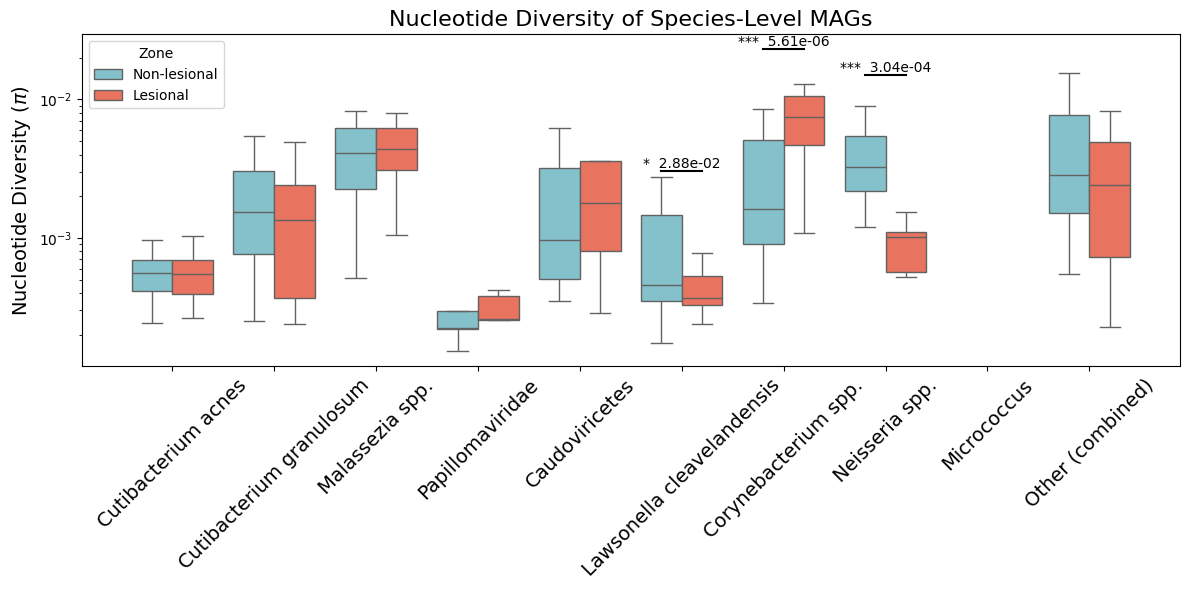

In [46]:
# Perform pairwise Mann-Whitney U test for each microbe, including All MAGs
results = []

# Get unique values in 'name' column, excluding 'All MAGs'
unique_microbes = [microbe for microbe in df_combined['name'].unique() if microbe != 'All MAGs']

for microbe in unique_microbes:
    # Subset the data for the current microbe or All MAGs
    microbe_data = df_combined[df_combined['name'] == microbe]
    
    # Split the data into Non-lesional and Lesional groups
    non_lesional = microbe_data[microbe_data['Zone'] == 'Non-lesional']['nucl_diversity']
    lesional = microbe_data[microbe_data['Zone'] == 'Lesional']['nucl_diversity']
    
    # Perform Mann-Whitney U test
    if len(non_lesional) > 0 and len(lesional) > 0:  # Ensure there are data points in both groups
        stat, p_value = mannwhitneyu(non_lesional, lesional, alternative='two-sided')
        results.append({'Microbe': microbe, 'p_value': p_value})
    else:
        results.append({'Microbe': microbe, 'p_value': float('nan')})  # Append NaN if one group is empty

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Define a new color palette for Lesional and Non-lesional samples
palette_zone = {'Lesional': '#FF6347',  # Tomato Red
                'Non-lesional': '#7AC9D5'}  # Blue Green

# Define the desired order of microbes
microbe_order = ['Cutibacterium acnes', 'Cutibacterium granulosum', 'Malassezia spp.', 'Papillomaviridae', 
                 'Caudoviricetes', 'Lawsonella cleavelandensis', 'Corynebacterium spp.', 'Neisseria spp.', 'Micrococcus', 'Other (combined)']

# Create boxplot for each microbe with zone (Non-lesional vs Lesional), including All MAGs
plt.figure(figsize=(12, 6))
sns.boxplot(x='name', y='nucl_diversity', hue='Zone', data=df_combined, 
            palette=palette_zone, hue_order=['Non-lesional', 'Lesional'], order=microbe_order, showfliers=False)

# Rotate x-axis labels for clarity
plt.xticks(rotation=45, fontsize=14)

# Set y-axis to log scale for better visualization of differences
plt.yscale('log')
plt.yticks([1e-4, 1e-3, 1e-2], ['10$^{-4}$', '10$^{-3}$', '10$^{-2}$'])

# Add labels and title
plt.xlabel('')
plt.ylabel('Nucleotide Diversity ($\pi$)', fontsize=14)
plt.title('Nucleotide Diversity of Species-Level MAGs', fontsize=16)

# Iterate over the results to add significance lines and asterisks for significant p-values
for i, row in results_df.iterrows():
    # Only proceed if the p-value is <= 0.05
    if row['p_value'] <= 0.05:
        # Determine the significance label based on p-value thresholds
        if row['p_value'] < 0.001:
            significance = '***  ' + f"{row['p_value']:.2e}"
        elif row['p_value'] < 0.01:
            significance = '**  ' + f"{row['p_value']:.2e}"
        else:
            significance = '*  ' + f"{row['p_value']:.2e}"

        # Get the x position of the current microbe based on its index in microbe_order
        microbe_idx = microbe_order.index(row['Microbe'])
        x1 = microbe_idx - 0.2  # Position for Non-lesional
        x2 = microbe_idx + 0.2  # Position for Lesional
        y = df_combined[df_combined['name'] == row['Microbe']]['nucl_diversity'].max() * 1.1  # Max y position

        # Draw the horizontal line and display the significance
        plt.plot([x1, x2], [y, y], color='k', lw=1.5)

        # Add an asterisk above the line, based on significance level
        plt.text((x1 + x2) / 2, y * 1, significance, ha='center', va='bottom', color='black')

# Display the plot
plt.tight_layout()

# Save and show the figure
plt.savefig(f'../Figures/metaG_Figures/inStrain/inStrain_nucleotide_diversity_species.png', dpi=600, bbox_inches='tight', pad_inches=0.1)  # Save as png
plt.savefig(f'../Figures/metaG_Figures/inStrain/inStrain_nucleotide_diversity_species.svg')  # Save as svg
plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:46: SyntaxWarning: invalid escape sequence '\p'
/var/folders/22/yck9vwx53w1c38tvj_c0_tz00000gn/T/ipykernel_65597/81959145.py:46: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('Nucleotide Diversity ($\pi$)', fontsize=14)


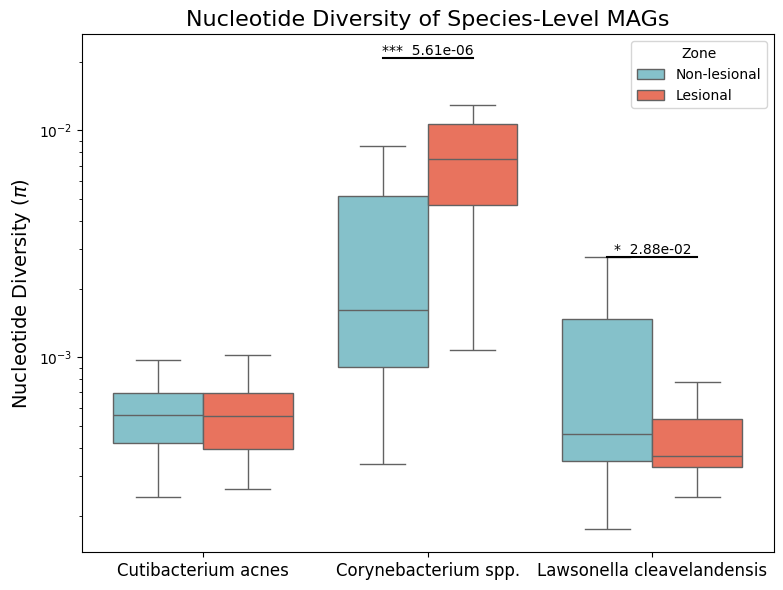

In [47]:
# Perform pairwise Mann-Whitney U test for each microbe, including All MAGs
results = []

# Get unique values in 'name' column, excluding 'All MAGs'
unique_microbes = ['Cutibacterium acnes', 'Corynebacterium spp.', 'Lawsonella cleavelandensis']

for microbe in unique_microbes:
    # Subset the data for the current microbe or All MAGs
    microbe_data = df_combined[df_combined['name'] == microbe]
    
    # Split the data into Non-lesional and Lesional groups
    non_lesional = microbe_data[microbe_data['Zone'] == 'Non-lesional']['nucl_diversity']
    lesional = microbe_data[microbe_data['Zone'] == 'Lesional']['nucl_diversity']
    
    # Perform Mann-Whitney U test
    if len(non_lesional) > 0 and len(lesional) > 0:  # Ensure there are data points in both groups
        stat, p_value = mannwhitneyu(non_lesional, lesional, alternative='two-sided')
        results.append({'Microbe': microbe, 'p_value': p_value})
    else:
        results.append({'Microbe': microbe, 'p_value': float('nan')})  # Append NaN if one group is empty

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Define a new color palette for Lesional and Non-lesional samples
palette_zone = {'Lesional': '#FF6347',  # Tomato Red
                'Non-lesional': '#7AC9D5'}  # Blue Green

# Define the desired order of microbes
microbe_order = ['Cutibacterium acnes', 'Corynebacterium spp.', 'Lawsonella cleavelandensis']

# Create boxplot for each microbe with zone (Non-lesional vs Lesional), including All MAGs
plt.figure(figsize=(8, 6))
sns.boxplot(x='name', y='nucl_diversity', hue='Zone', data=df_combined, 
            palette=palette_zone, hue_order=['Non-lesional', 'Lesional'], order=microbe_order, showfliers=False)

# Rotate x-axis labels for clarity
plt.xticks(fontsize=12)

# Set y-axis to log scale for better visualization of differences
plt.yscale('log')
plt.yticks([1e-4, 1e-3, 1e-2], ['10$^{-4}$', '10$^{-3}$', '10$^{-2}$'])

# Add labels and title
plt.xlabel('')
plt.ylabel('Nucleotide Diversity ($\pi$)', fontsize=14)
plt.title('Nucleotide Diversity of Species-Level MAGs', fontsize=16)

# Iterate over the results to add significance lines and asterisks for significant p-values
for i, row in results_df.iterrows():
    # Only proceed if the p-value is <= 0.05
    if row['p_value'] <= 0.05:
        # Determine the significance label based on p-value thresholds
        if row['p_value'] < 0.001:
            significance = '***  ' + f"{row['p_value']:.2e}"
        elif row['p_value'] < 0.01:
            significance = '**  ' + f"{row['p_value']:.2e}"
        else:
            significance = '*  ' + f"{row['p_value']:.2e}"

        # Get the x position of the current microbe based on its index in microbe_order
        microbe_idx = microbe_order.index(row['Microbe'])
        x1 = microbe_idx - 0.2  # Position for Non-lesional
        x2 = microbe_idx + 0.2  # Position for Lesional
        y = df_combined[df_combined['name'] == row['Microbe']]['nucl_diversity'].max() * 1  # Max y position

        # Draw the horizontal line and display the significance
        plt.plot([x1, x2], [y, y], color='k', lw=1.5)

        # Add an asterisk above the line, based on significance level
        plt.text((x1 + x2) / 2, y * 1, significance, ha='center', va='bottom', color='black')

# Display the plot
plt.tight_layout()

# Save and show the figure
plt.savefig(f'../Figures/metaG_Figures/inStrain/inStrain_nucleotide_diversity_top3.png', dpi=600, bbox_inches='tight', pad_inches=0.1)  # Save as png
plt.savefig(f'../Figures/metaG_Figures/inStrain/inStrain_nucleotide_diversity_top3.svg')  # Save as svg
plt.show()

## Nucleotide diversity results from inStrain based on MAGs grouped by _C. acnes_ MLST strain type

In [48]:
# Read in merged genome_info file
path = '../Data/metaG/VEBA_analysis/output_files/X_mags.with_taxonomy.with_slcs_c.acnes.csv'
taxa = pd.read_csv(path, sep=',')
taxa.head()

,SLC,sample_mag,organism_type,taxonomy,c. acnes,LAMI_RD308_D9_C3_S18_L005,LAMI_RD306_D28_C3_S12_L005,LAMI_RD310_D16_C2_S22_L005,LAMI_RD304_D14_C3_S4_L005,LAMI_RD304_D11_C1_S3_L005,...,LAMI_RD304_D28_C3_S5_L005,LAMI_RD308_D0_C2_S13_L005,LAMI_RD310_D0_C2_S19_L005,LAMI_RD306_D11_C1_S8_L005,LAMI_RD310_D0_C3_S20_L005,LAMI_RD310_D14_C3_S21_L005,LAMI_RD306_D14_C1_S9_L005,LAMI_RD310_D21_C2_S23_L005,LAMI_RD308_D14_C3_S16_L005,LAMI_RD304_D0_C1_S1_L005
0,PSLC-1,LAMI_RD306_D0_C3_S7_L005__MAXBIN2-40__P.1__bin...,prokaryotic,d__Bacteria;p__Actinomycetota;c__Actinomycetia...,C. acnes Type IA (MAG 1),777667,1513946,19467,127037,5905,...,362236,1811,196880,825942,372845,441798,83571,196812,782381,111499
1,PSLC-2,LAMI_RD306_D0_C3_S7_L005__METABAT2__P.1__bin.2,prokaryotic,d__Bacteria;p__Actinomycetota;c__Actinomycetia...,NaN,14720,171159,1374,21838,896,...,60647,27,20516,65240,26311,13760,5157,28370,7988,23177
2,PSLC-7,LAMI_RD306_D11_C1_S8_L005__CONCOCT__P.1__14_sub,prokaryotic,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,NaN,5,74,0,35,1,...,57,0,1,102859,5,1,22,13,1,35
3,PSLC-11,LAMI_RD306_D11_C1_S8_L005__CONCOCT__P.1__26,prokaryotic,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,NaN,31,69,0,3,0,...,4,0,1,764138,0,0,25,0,3,1
4,PSLC-3,LAMI_RD306_D11_C1_S8_L005__CONCOCT__P.1__27,prokaryotic,d__Bacteria;p__Actinomycetota;c__Actinomycetia...,NaN,1217,72530,123,7890,258,...,4476,4,661,94133,819,446,11267,970,635,2289


In [49]:
# Merge the 'taxonomy' column from taxa into df based on matching 'genome' in df with 'Unnamed:1' in taxa
df = df.merge(taxa[['sample_mag', 'c. acnes']], how='left', left_on='genome', right_on='sample_mag')
df = df.drop(columns=['sample_mag'])

# Add zone info 
df = df.merge(md[['sample_name', 'Zone']], how='left', left_on='sample_id', right_on='sample_name')

# Drop genomes where nucl_diverity is NaN
df = df.dropna(subset=['nucl_diversity'])

# Filter the DataFrame for nucl_diversity > 0
df = df[(df['nucl_diversity'] > 0.0)]

In [50]:
# Get the maximum value in the 'nucl_diversity' column
max_value = df['nucl_diversity'].max()

# Get the minimum value in the 'breath' column
min_value = df['nucl_diversity'].min()

# Print the results
print(f"Max nucl_diversity: {max_value}")
print(f"Min nucl_diversity: {min_value}")

Max nucl_diversity: 0.0208695660466733
Min nucl_diversity: 0.0001193115662337


In [51]:
# Get the maximum value in the 'breadth' column
max_value = df['breadth'].max()

# Get the minimum value in the 'breath' column
min_value = df['breadth'].min()

# Print the results
print(f"Max breadth: {max_value}")
print(f"Min breadth: {min_value}")

Max breadth: 0.9999323295550668
Min breadth: 0.0006918139730639


In [52]:
# Sort by nucl_diversity column
df = df.sort_values(by='nucl_diversity', ascending=False)

# Rename Zone_x to Zone
df = df.rename(columns={'Zone_x': 'Zone'})

# Drop the Zone_y column
df = df.drop(columns=['Zone_y'])

df.head()

,genome,coverage,breadth,nucl_diversity,length,true_scaffolds,detected_scaffolds,coverage_median,coverage_std,coverage_SEM,...,reads_mean_PID,reads_unfiltered_reads,divergent_site_count,sample_id,local_lesion_severity,subject_ID,name,Zone,c. acnes,sample_name
922,LAMI_RD306_D23_C1_S11_L005__CONCOCT__P.1__4,0.032903,0.028253,0.020870,2271160.0,116.0,95.0,0,0.209191,0.000140,...,0.980361,1184.0,4.0,LAMI.RD306.D23.C1,2,PP_306,Corynebacterium spp.,Lesional,NaN,LAMI.RD306.D23.C1
143,LAMI_RD308_D23_C2_S17_L005__CONCOCT__P.1__3_sub,1.311266,0.495348,0.017373,1239730.0,441.0,400.0,1,1.955700,0.001822,...,0.956687,3088.0,34567.0,LAMI.RD308.D23.C2,4,PP_308,Streptococcus mitis,Lesional,NaN,LAMI.RD308.D23.C2
710,LAMI_RD306_D28_C3_S12_L005__MAXBIN2-107__P.2__...,2.859724,0.556719,0.015418,2177234.0,946.0,749.0,1,3.985881,0.002827,...,0.977361,16184.0,96968.0,LAMI.RD306.D28.C3,1,PP_306,Other (combined),Non-lesional,NaN,LAMI.RD306.D28.C3
188,LAMI_RD308_D23_C2_S17_L005__CONCOCT__P.1__3_sub,0.099173,0.072122,0.014762,1239730.0,441.0,244.0,0,0.415691,0.000387,...,0.954242,26.0,2748.0,LAMI.RD308.D23.C2,4,PP_308,Streptococcus mitis,Lesional,NaN,LAMI.RD308.D23.C2
473,LAMI_RD306_D14_C3_S10_L005__GENOMAD__Virus.2,5.587592,0.791820,0.014069,29095.0,1.0,1.0,2,7.644102,0.044970,...,0.961706,3217.0,405.0,LAMI.RD306.D14.C3,0,PP_306,Caudoviricetes,Non-lesional,NaN,LAMI.RD306.D14.C3


In [53]:
# Extract the 'C. acnes Type **' part
df['c. acnes'] = df['c. acnes'].str.extract(r'(C\. acnes Type \S+)')

# Filter rows where the 'c. acnes' column has non-null values
df = df[df['c. acnes'].notna()]
df.head()

,genome,coverage,breadth,nucl_diversity,length,true_scaffolds,detected_scaffolds,coverage_median,coverage_std,coverage_SEM,...,reads_mean_PID,reads_unfiltered_reads,divergent_site_count,sample_id,local_lesion_severity,subject_ID,name,Zone,c. acnes,sample_name
990,LAMI_RD306_D11_C1_S8_L005__MAXBIN2-40__P.1__bi...,1.301884,0.677695,0.001026,2518872.0,21.0,21.0,1,1.335021,0.000842,...,0.997679,44887.0,71.0,LAMI.RD306.D11.C1,2,PP_306,Cutibacterium acnes,Lesional,C. acnes Type IA,LAMI.RD306.D11.C1
471,LAMI_RD306_D14_C1_S9_L005__MAXBIN2-107__P.1__b...,78.123701,0.999332,0.000989,2474277.0,24.0,24.0,80,33.969821,0.021617,...,0.997683,2462312.0,4452.0,LAMI.RD306.D14.C1,1,PP_306,Cutibacterium acnes,Lesional,C. acnes Type IA,LAMI.RD306.D14.C1
464,LAMI_RD306_D0_C3_S7_L005__MAXBIN2-40__P.1__bin...,75.706135,0.997471,0.000972,2504338.0,33.0,33.0,79,28.564490,0.018074,...,0.997771,2413175.0,4334.0,LAMI.RD306.D0.C3,1,PP_306,Cutibacterium acnes,Non-lesional,C. acnes Type IA,LAMI.RD306.D0.C3
474,LAMI_RD306_D14_C3_S10_L005__MAXBIN2-107__P.1__...,76.065363,0.999347,0.000965,2521045.0,22.0,22.0,79,31.460426,0.019831,...,0.997523,2438875.0,4425.0,LAMI.RD306.D14.C3,0,PP_306,Cutibacterium acnes,Non-lesional,C. acnes Type IA,LAMI.RD306.D14.C3
484,LAMI_RD306_D28_C3_S12_L005__MAXBIN2-107__P.1__...,77.565046,0.999498,0.000961,2449784.0,35.0,35.0,80,29.828279,0.019085,...,0.997633,2421567.0,4149.0,LAMI.RD306.D28.C3,1,PP_306,Cutibacterium acnes,Non-lesional,C. acnes Type IA,LAMI.RD306.D28.C3


<>:30: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\p'
/var/folders/22/yck9vwx53w1c38tvj_c0_tz00000gn/T/ipykernel_65597/1883747518.py:30: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('Nucleotide Diversity ($\pi$)', fontsize=14)


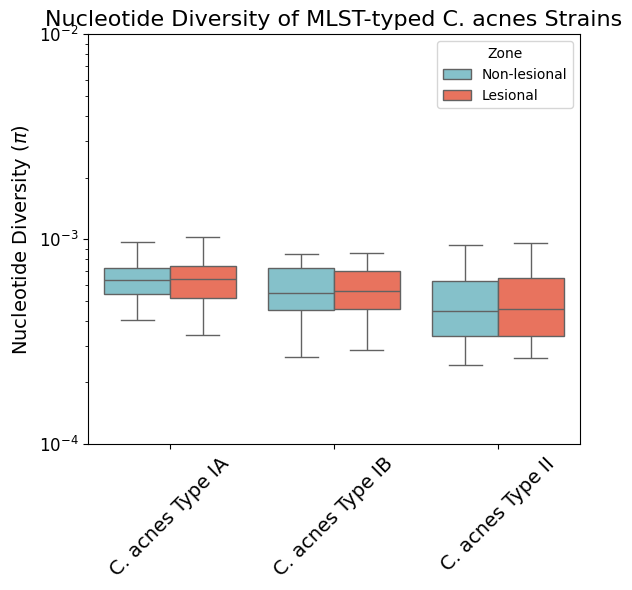

In [54]:
# Filter the DataFrame for Non-lesional and Lesional samples and key microbes
key_microbes = ['C. acnes Type IA', 'C. acnes Type IB', 'C. acnes Type II']
df_key_microbes = df[(df['c. acnes'].isin(key_microbes)) & (df['Zone'].isin(['Non-lesional', 'Lesional']))]

# Create a new row with 'All MAGs' to represent combined nucleotide diversity for all microbes
# df_all_mags = df[df['zone'].isin(['Non-lesional', 'Lesional'])].copy()
# df_all_mags['c. acnes'] = 'All MAGs'

# Combine the "All MAGs" row with the filtered key microbes DataFrame
df_combined = pd.concat([df_key_microbes])

# Define a new color palette for Lesional and Non-lesional samples
palette_zone = {'Lesional': '#FF6347',  # Tomato Red
                'Non-lesional': '#7AC9D5'}  # Cornflower Blue

# Create boxplot for each microbe with zone (Non-lesional vs Lesional), including All MAGs
plt.figure(figsize=(6, 6))
sns.boxplot(x='c. acnes', y='nucl_diversity', hue='Zone', data=df_combined, 
            palette=palette_zone, hue_order=['Non-lesional', 'Lesional'], showfliers=False, order=key_microbes)

# Rotate x-axis labels for clarity
plt.xticks(rotation=45, fontsize=14)

# Set y-axis to log scale for better visualization of differences
plt.yscale('log')
plt.yticks([1e-4, 1e-3, 1e-2], ['10$^{-4}$', '10$^{-3}$', '10$^{-2}$'], fontsize=12)

# Add labels, title, and tight layout format
plt.xlabel('')
plt.ylabel('Nucleotide Diversity ($\pi$)', fontsize=14)
plt.title('Nucleotide Diversity of MLST-typed C. acnes Strains', fontsize=16)
plt.tight_layout()

# Save and show the figure
plt.savefig(f'../Figures/metaG_Figures/inStrain/inStrain_nucleotide_diversity_cacnes.png', dpi=600, bbox_inches='tight', pad_inches=0.1)  # Save as png
plt.savefig(f'../Figures/metaG_Figures/inStrain/inStrain_nucleotide_diversity_cacnes.svg')  # Save as svg
plt.show()

## dN/dS analysis from inStrain profile using --gene (prodigal .fna file)

In [55]:
# Read in concatenated gene info file which contains dNdS_substitutions column
gene_info = pd.read_csv('../Data/metaG/inStrain_files/all_gene_info.tsv', sep='\t')

In [56]:
# Add genome column from all_SNP_mutation_types file
all_SNP_mutation_types = pd.read_csv('../Data/metaG/inStrain_files/all_SNP_mutation_types_with_genome.csv')

# Merge gene_info_df with all_SNP_mutation_types_df on the 'scaffold' column to add the 'genome' column
gene_info = gene_info.merge(all_SNP_mutation_types[['scaffold', 'genome']], on='scaffold', how='left')

# Remove rows where 'dNdS_substitutions' is NaN
gene_info = gene_info.dropna(subset=['dNdS_substitutions'])

# Check dataframe
gene_info.head()

,scaffold,gene,gene_length,coverage,breadth,breadth_minCov,nucl_diversity,start,end,direction,...,dNdS_substitutions,pNpS_variants,SNV_count,SNV_S_count,SNV_N_count,SNS_count,SNS_S_count,SNS_N_count,divergent_site_count,genome
332767,LAMI_RD304_D0_C3_S2_L005__NODE_2_length_369923...,LAMI_RD304_D0_C3_S2_L005__NODE_2_length_369923...,1431.0,44.324249,0.995807,0.984626,0.002901,86168,87598,1,...,0.0,0.198086,14.0,9.0,5.0,1.0,1.0,0.0,15.0,LAMI_RD304_D0_C3_S2_L005__MAXBIN2-107__P.1__bi...
332768,LAMI_RD304_D0_C3_S2_L005__NODE_2_length_369923...,LAMI_RD304_D0_C3_S2_L005__NODE_2_length_369923...,1431.0,44.324249,0.995807,0.984626,0.002901,86168,87598,1,...,0.0,0.198086,14.0,9.0,5.0,1.0,1.0,0.0,15.0,LAMI_RD304_D0_C3_S2_L005__MAXBIN2-107__P.1__bi...
332769,LAMI_RD304_D0_C3_S2_L005__NODE_2_length_369923...,LAMI_RD304_D0_C3_S2_L005__NODE_2_length_369923...,1431.0,44.324249,0.995807,0.984626,0.002901,86168,87598,1,...,0.0,0.198086,14.0,9.0,5.0,1.0,1.0,0.0,15.0,LAMI_RD304_D0_C3_S2_L005__MAXBIN2-107__P.1__bi...
332770,LAMI_RD304_D0_C3_S2_L005__NODE_2_length_369923...,LAMI_RD304_D0_C3_S2_L005__NODE_2_length_369923...,1431.0,44.324249,0.995807,0.984626,0.002901,86168,87598,1,...,0.0,0.198086,14.0,9.0,5.0,1.0,1.0,0.0,15.0,LAMI_RD304_D0_C3_S2_L005__MAXBIN2-107__P.1__bi...
332771,LAMI_RD304_D0_C3_S2_L005__NODE_2_length_369923...,LAMI_RD304_D0_C3_S2_L005__NODE_2_length_369923...,1431.0,44.324249,0.995807,0.984626,0.002901,86168,87598,1,...,0.0,0.198086,14.0,9.0,5.0,1.0,1.0,0.0,15.0,LAMI_RD304_D0_C3_S2_L005__MAXBIN2-107__P.1__bi...


In [57]:
# Read in merged genome_info file
path = '../Data/metaG/VEBA_analysis/output_files/X_mags.with_taxonomy.with_slcs_name.csv'
taxa = pd.read_csv(path, sep=',')
taxa.head()

,SLC,sample_mag,organism_type,taxonomy,name,LAMI_RD308_D9_C3_S18_L005,LAMI_RD306_D28_C3_S12_L005,LAMI_RD310_D16_C2_S22_L005,LAMI_RD304_D14_C3_S4_L005,LAMI_RD304_D11_C1_S3_L005,...,LAMI_RD304_D28_C3_S5_L005,LAMI_RD308_D0_C2_S13_L005,LAMI_RD310_D0_C2_S19_L005,LAMI_RD306_D11_C1_S8_L005,LAMI_RD310_D0_C3_S20_L005,LAMI_RD310_D14_C3_S21_L005,LAMI_RD306_D14_C1_S9_L005,LAMI_RD310_D21_C2_S23_L005,LAMI_RD308_D14_C3_S16_L005,LAMI_RD304_D0_C1_S1_L005
0,PSLC-1,LAMI_RD306_D0_C3_S7_L005__MAXBIN2-40__P.1__bin...,prokaryotic,d__Bacteria;p__Actinomycetota;c__Actinomycetia...,Cutibacterium acnes,777667,1513946,19467,127037,5905,...,362236,1811,196880,825942,372845,441798,83571,196812,782381,111499
1,PSLC-2,LAMI_RD306_D0_C3_S7_L005__METABAT2__P.1__bin.2,prokaryotic,d__Bacteria;p__Actinomycetota;c__Actinomycetia...,Cutibacterium granulosum,14720,171159,1374,21838,896,...,60647,27,20516,65240,26311,13760,5157,28370,7988,23177
2,PSLC-7,LAMI_RD306_D11_C1_S8_L005__CONCOCT__P.1__14_sub,prokaryotic,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,Other (combined),5,74,0,35,1,...,57,0,1,102859,5,1,22,13,1,35
3,PSLC-11,LAMI_RD306_D11_C1_S8_L005__CONCOCT__P.1__26,prokaryotic,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,Other (combined),31,69,0,3,0,...,4,0,1,764138,0,0,25,0,3,1
4,PSLC-3,LAMI_RD306_D11_C1_S8_L005__CONCOCT__P.1__27,prokaryotic,d__Bacteria;p__Actinomycetota;c__Actinomycetia...,Lawsonella cleavelandensis,1217,72530,123,7890,258,...,4476,4,661,94133,819,446,11267,970,635,2289


In [58]:
# Merge gene_info_df with taxa_df on the 'genome' and 'sample_mag' columns to add the 'name' column
gene_info = gene_info.merge(taxa[['sample_mag', 'name']], left_on='genome', right_on='sample_mag', how='left')

# Drop the extra 'sample_mag' column after merging
gene_info.drop(columns=['sample_mag'], inplace=True)

# Add a new column 'sample_name' to gene_info_df
# Extract everything before the 4th underscore and replace underscores with dots
gene_info['sample_name'] = gene_info['scaffold'].str.extract(r'^((?:[^_]*_){3}[^_]*)')[0].str.replace('_', '.', regex=False)

# Merge the 'Zone' column from md into gene_info_df based on 'sample_name'
gene_info = gene_info.merge(md[['sample_name', 'Zone']], on='sample_name', how='left')

# Sort gene_info_df by 'dNdS_substitutions' column in descending order
gene_info = gene_info.sort_values(by='dNdS_substitutions', ascending=False)

# Check dataframe
gene_info.head()


,scaffold,gene,gene_length,coverage,breadth,breadth_minCov,nucl_diversity,start,end,direction,...,SNV_S_count,SNV_N_count,SNS_count,SNS_S_count,SNS_N_count,divergent_site_count,genome,name,sample_name,Zone
80975,LAMI_RD306_D28_C3_S12_L005__NODE_3317_length_1...,LAMI_RD306_D28_C3_S12_L005__NODE_3317_length_1...,1746.0,11.06071,0.936426,0.718786,0.014279,1,1746,1,...,29.0,10.0,7.0,1.0,6.0,46.0,LAMI_RD306_D28_C3_S12_L005__METABAT2__P.1__bin.10,Micrococcus spp.,LAMI.RD306.D28.C3,Non-lesional
80959,LAMI_RD306_D28_C3_S12_L005__NODE_3317_length_1...,LAMI_RD306_D28_C3_S12_L005__NODE_3317_length_1...,1746.0,11.06071,0.936426,0.718786,0.014279,1,1746,1,...,29.0,10.0,7.0,1.0,6.0,46.0,LAMI_RD306_D28_C3_S12_L005__METABAT2__P.1__bin.10,Micrococcus spp.,LAMI.RD306.D28.C3,Non-lesional
80961,LAMI_RD306_D28_C3_S12_L005__NODE_3317_length_1...,LAMI_RD306_D28_C3_S12_L005__NODE_3317_length_1...,1746.0,11.06071,0.936426,0.718786,0.014279,1,1746,1,...,29.0,10.0,7.0,1.0,6.0,46.0,LAMI_RD306_D28_C3_S12_L005__METABAT2__P.1__bin.10,Micrococcus spp.,LAMI.RD306.D28.C3,Non-lesional
80962,LAMI_RD306_D28_C3_S12_L005__NODE_3317_length_1...,LAMI_RD306_D28_C3_S12_L005__NODE_3317_length_1...,1746.0,11.06071,0.936426,0.718786,0.014279,1,1746,1,...,29.0,10.0,7.0,1.0,6.0,46.0,LAMI_RD306_D28_C3_S12_L005__METABAT2__P.1__bin.10,Micrococcus spp.,LAMI.RD306.D28.C3,Non-lesional
80964,LAMI_RD306_D28_C3_S12_L005__NODE_3317_length_1...,LAMI_RD306_D28_C3_S12_L005__NODE_3317_length_1...,1746.0,11.06071,0.936426,0.718786,0.014279,1,1746,1,...,29.0,10.0,7.0,1.0,6.0,46.0,LAMI_RD306_D28_C3_S12_L005__METABAT2__P.1__bin.10,Micrococcus spp.,LAMI.RD306.D28.C3,Non-lesional


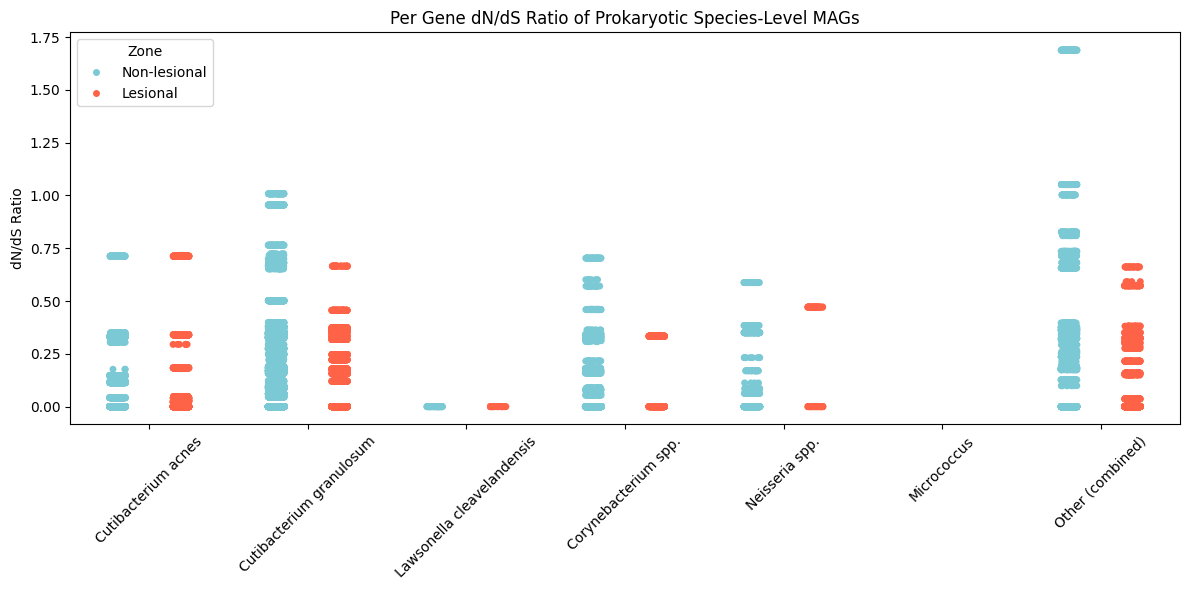

In [59]:
# Plot Figure

# Define custom color palette for 'Lesional' and 'Non-lesional' zones
palette_zone = {'Lesional': '#FF6347',  # Tomato Red for Lesional
                'Non-lesional': '#7AC9D5'}  # Cornflower Blue for Non-lesional

# Specify the desired order for microbes along the x-axis
microbe_order = ['Cutibacterium acnes', 'Cutibacterium granulosum', 'Lawsonella cleavelandensis', 
                 'Corynebacterium spp.', 'Neisseria spp.', 'Micrococcus', 'Other (combined)']

# Set the figure size
plt.figure(figsize=(12, 6))

# Create a strip plot of dN/dS substitutions by microbe and zone
sns.stripplot(data=gene_info, x='name', y='dNdS_substitutions', hue='Zone', 
              jitter=True, dodge=True, palette=palette_zone, order=microbe_order)

# Set the plot title and axis labels
plt.title('Per Gene dN/dS Ratio of Prokaryotic Species-Level MAGs')  # Main plot title
plt.ylabel('dN/dS Ratio')  # Y-axis label for dN/dS ratios
plt.xlabel('')  # Empty x-axis label as microbe names are already displayed

# Rotate x-axis labels for better readability if names are long
plt.xticks(rotation=45)

# Set legend title to 'Zone' to clarify Lesional vs. Non-lesional grouping
plt.legend(title='Zone', loc='upper left')

# Adjust layout to prevent clipping of labels/titles
plt.tight_layout()

# Save and show the figure
plt.savefig(f'../Figures/metaG_Figures/inStrain/inStrain_dnds_prokaryotic-species.png', dpi=600, bbox_inches='tight', pad_inches=0.1)  # Save as png
plt.savefig(f'../Figures/metaG_Figures/inStrain/inStrain_dnds_prokaryotic-species.svg')  # Save as svg
plt.show()


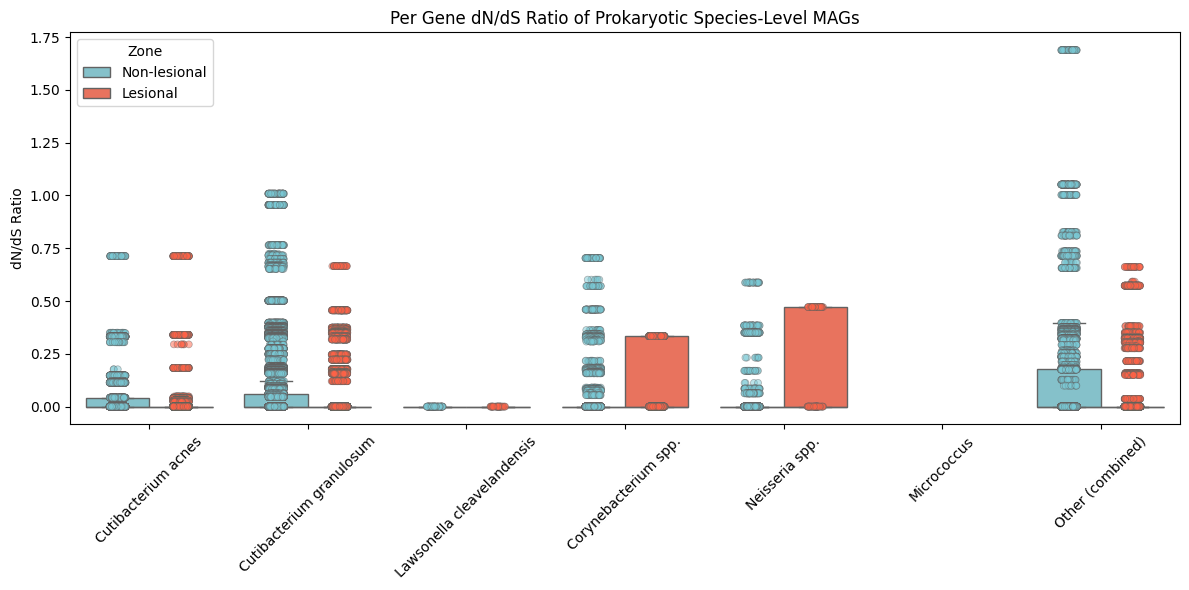

In [60]:
# Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Define custom color palette for 'Lesional' and 'Non-lesional' zones
palette_zone = {'Lesional': '#FF6347',  # Tomato Red for Lesional
                'Non-lesional': '#7AC9D5'}  # Cornflower Blue for Non-lesional

# Specify the desired order for microbes along the x-axis
microbe_order = ['Cutibacterium acnes', 'Cutibacterium granulosum', 'Lawsonella cleavelandensis', 
                 'Corynebacterium spp.', 'Neisseria spp.', 'Micrococcus', 'Other (combined)']

# Set the figure size
plt.figure(figsize=(12, 6))

# Create a boxplot of dN/dS substitutions by microbe and zone
sns.boxplot(data=gene_info, x='name', y='dNdS_substitutions', hue='Zone', 
            palette=palette_zone, order=microbe_order, dodge=True, showfliers=False)

# Overlay a strip plot for individual data points
sns.stripplot(data=gene_info, x='name', y='dNdS_substitutions', hue='Zone', 
              palette=palette_zone, order=microbe_order, dodge=True, alpha=0.5, jitter=True, linewidth=0.5)

# Set the plot title and axis labels
plt.title('Per Gene dN/dS Ratio of Prokaryotic Species-Level MAGs')  # Main plot title
plt.ylabel('dN/dS Ratio')  # Y-axis label for dN/dS ratios
plt.xlabel('')  # Empty x-axis label as microbe names are already displayed

# Rotate x-axis labels for better readability if names are long
plt.xticks(rotation=45)

# Adjust the legend to prevent duplication from overlaying plots
handles, labels = plt.gca().get_legend_handles_labels()
unique_handles = handles[:len(palette_zone)]
unique_labels = labels[:len(palette_zone)]
plt.legend(unique_handles, unique_labels, title='Zone', loc='upper left')

# Adjust layout to prevent clipping of labels/titles
plt.tight_layout()

# Save and show the figure
plt.savefig(f'../Figures/metaG_Figures/inStrain/inStrain_dnds_prokaryotic-species_boxplot.png', dpi=600, bbox_inches='tight', pad_inches=0.1)  # Save as png
plt.savefig(f'../Figures/metaG_Figures/inStrain/inStrain_dnds_prokaryotic-species_boxplot.svg')  # Save as svg
plt.show()
